# **Data Importation**

## Loading Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("GSSsubset.csv")
data.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


## Examination of dataset

In [3]:
data.tail(10)

,id,sex,degree,income,marital,age,height,weight,hrswrk
984,2523,MALE,BACHELOR,24017.50,MARRIED,54,72,195,40
985,2524,MALE,BACHELOR,33255.00,MARRIED,49,70,195,40
986,2525,FEMALE,BACHELOR,33255.00,MARRIED,53,64,150,40
987,2526,MALE,BACHELOR,40645.00,MARRIED,52,72,200,50
988,2530,MALE,HIGH SCHOOL,33255.00,MARRIED,62,71,215,48
989,2531,MALE,HIGH SCHOOL,1478.00,NEVER MARRIED,40,71,230,48
990,2535,MALE,HIGH SCHOOL,33255.00,DIVORCED,56,72,195,46
991,2536,MALE,HIGH SCHOOL,8313.75,NEVER MARRIED,24,68,145,40
992,2537,MALE,HIGH SCHOOL,27712.50,NEVER MARRIED,27,68,180,40
993,2538,FEMALE,HIGH SCHOOL,15703.75,WIDOWED,71,63,140,48


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       994 non-null    int64  
 1   sex      994 non-null    object 
 2   degree   994 non-null    object 
 3   income   994 non-null    float64
 4   marital  994 non-null    object 
 5   age      994 non-null    int64  
 6   height   994 non-null    int64  
 7   weight   994 non-null    int64  
 8   hrswrk   994 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 70.0+ KB


## Data Cleaning and Preprocessing
### Handling Missing Values
#### Check for Missing Values

In [5]:
miss_values = data.isnull().sum()
miss_values

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

#### Remove rows with missing values

In [6]:
data.dropna(inplace = True)
miss_values = data.isnull().sum()
miss_values

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

### Identification of outliers using boxplot

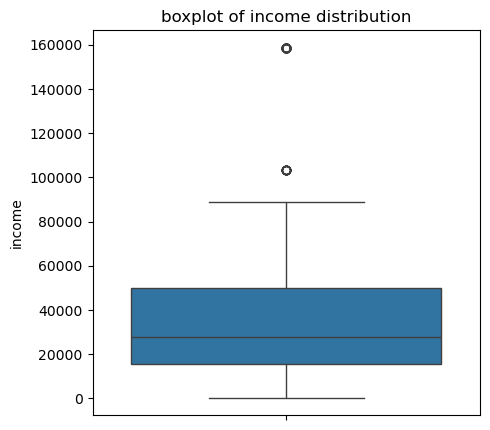

In [7]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data, y = "income")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

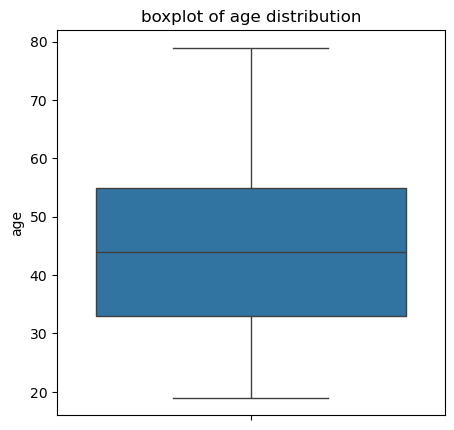

In [8]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data, y = "age")
plt.title("boxplot of age distribution")
plt.ylabel("age")
plt.show()

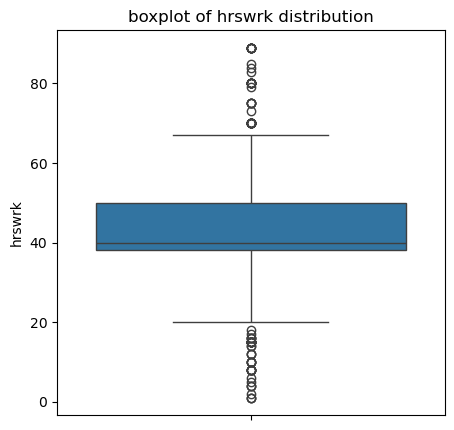

In [9]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data, y = "hrswrk")
plt.title("boxplot of hrswrk distribution")
plt.ylabel("hrswrk")
plt.show()

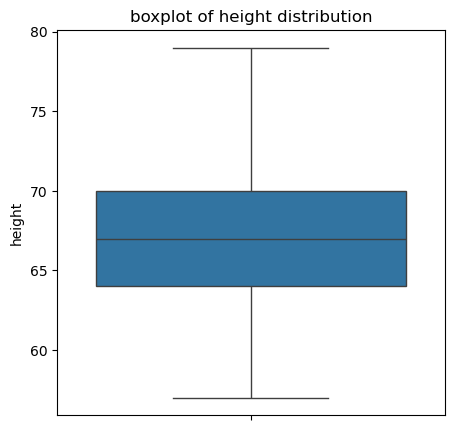

In [10]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data, y = "height")
plt.title("boxplot of height distribution")
plt.ylabel("height")
plt.show()

### Boxplot for all numerical variables

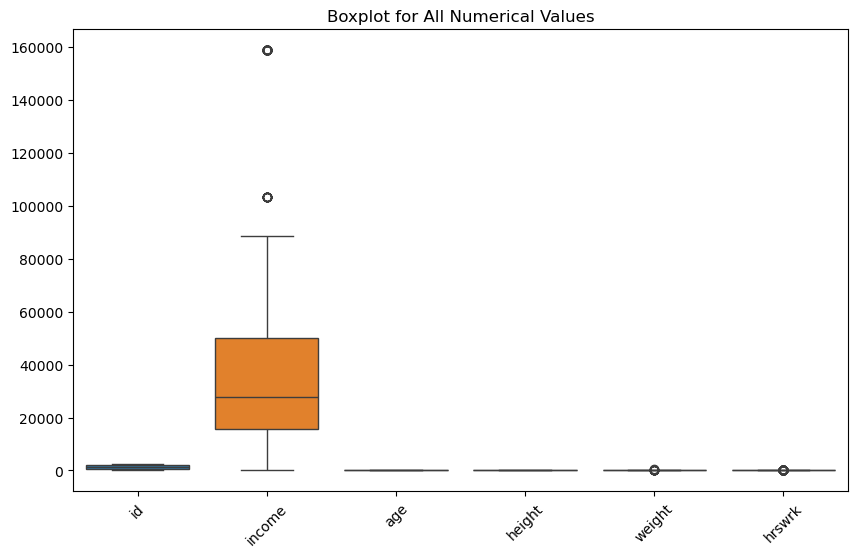

In [11]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = data)

# Customize plot
plt.xticks(rotation = 45)
plt.title("Boxplot for All Numerical Values")
plt.show()

### Removing outliers
#### 1. 1.5 Inter-Quartile Rule

In [12]:
# Calculate IQR
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# remove outliers
data_one = data[(data['income'] >= lower_bound) & (data['income'] <= upper_bound)]

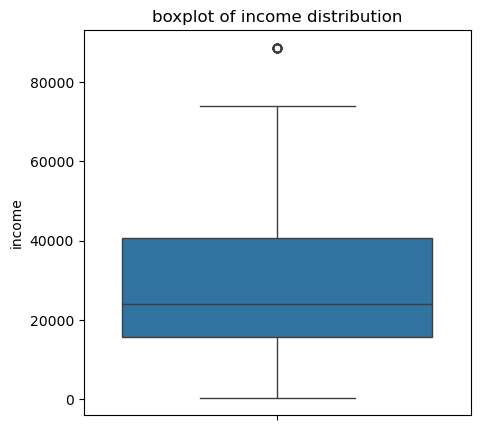

In [13]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data_one, y = "income")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

In [14]:
# Calculate IQR
Q1 = data_one['income'].quantile(0.25)
Q3 = data_one['income'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# remove outliers
data_two = data_one[(data_one['income'] >= lower_bound) & (data_one['income'] <= upper_bound)]

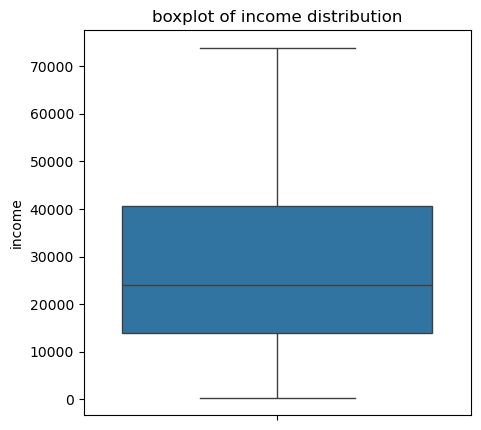

In [15]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data_two, y = "income")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

## Summary statistics

In [16]:
summary_statistics = data_two.describe()
summary_statistics

,id,income,age,height,weight,hrswrk
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,1297.983462,28125.794101,43.918412,67.206174,180.155458,41.750827
std,728.457647,18434.522770,13.160663,4.030026,41.859287,13.948490
min,1.000000,369.500000,19.000000,57.000000,90.000000,1.000000
25%,693.000000,13856.250000,33.000000,64.000000,150.000000,36.500000
50%,1288.000000,24017.500000,43.000000,67.000000,175.000000,40.000000
75%,1932.500000,40645.000000,54.000000,70.000000,202.500000,50.000000
max,2538.000000,73900.000000,79.000000,78.000000,410.000000,89.000000


In [17]:
summary_statistics = data_two.drop(columns = ['id']).describe()
summary_statistics

,income,age,height,weight,hrswrk
count,907.000000,907.000000,907.000000,907.000000,907.000000
mean,28125.794101,43.918412,67.206174,180.155458,41.750827
std,18434.522770,13.160663,4.030026,41.859287,13.948490
min,369.500000,19.000000,57.000000,90.000000,1.000000
25%,13856.250000,33.000000,64.000000,150.000000,36.500000
50%,24017.500000,43.000000,67.000000,175.000000,40.000000
75%,40645.000000,54.000000,70.000000,202.500000,50.000000
max,73900.000000,79.000000,78.000000,410.000000,89.000000


### Summary statistics for categorical variables

In [18]:
categorical_summary = data.describe(include = ["O"])
categorical_summary

,sex,degree,marital
count,994,994,994
unique,2,5,5
top,MALE,HIGH SCHOOL,MARRIED
freq,507,491,480


# Data Visualization
## Histogram

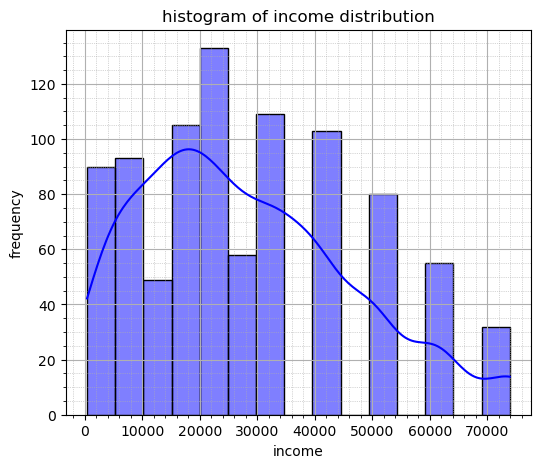

In [19]:
plt.figure(figsize = (6, 5))
sns.histplot(data = data_two, x = 'income', bins = 15, kde = True, color = 'blue')
plt.xlabel('income')
plt.ylabel('frequency')
plt.title('histogram of income distribution')
plt.minorticks_on()
plt.grid(which = 'minor', linestyle = ':', linewidth = 0.5)
plt.grid(True)
plt.show()

## Boxplot of income across degree

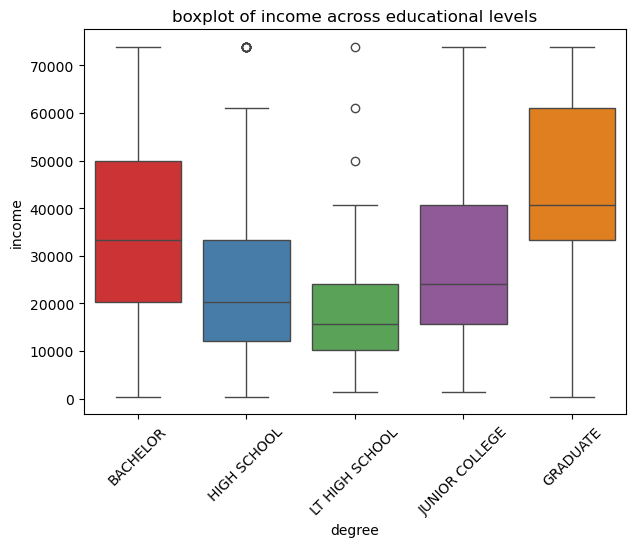

In [20]:
plt.figure(figsize = (7, 5))
sns.boxplot(data = data_two, x = 'degree', y = 'income', hue = 'degree', palette = 'Set1')
plt.xticks(rotation = 45)
plt.xlabel('degree')
plt.ylabel('income')
plt.title('boxplot of income across educational levels')
plt.show()

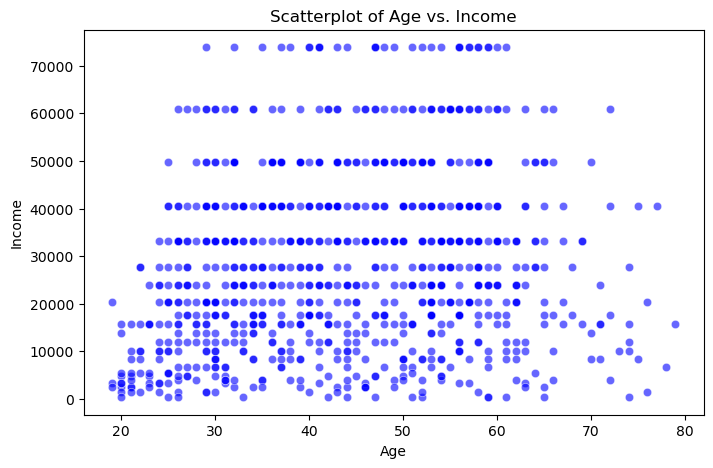

In [22]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = data_two, x = 'age', y = 'income', color = 'blue', alpha = 0.6)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Scatterplot of Age vs. Income')
plt.show()

# *Assignment*

In [23]:
data = pd.read_csv("data1.csv")
data.head()

,ID,Age,Income_USD,Education_Years,Work_Experience,Customer_Satisfaction,Monthly_Spending,gender
0,1,56.0,NaN,9.0,9.0,NaN,849.47,male
1,2,46.0,44250.15,19.0,39.0,4.0,1215.06,female
2,3,32.0,43062.10,17.0,37.0,7.0,1092.33,male
3,4,60.0,33312.54,20.0,5.0,3.0,1165.54,female
4,5,25.0,63008.44,13.0,7.0,2.0,1128.40,female


In [24]:
data.tail(10)

,ID,Age,Income_USD,Education_Years,Work_Experience,Customer_Satisfaction,Monthly_Spending,gender
290,291,46.0,36379.19,10.0,20.0,1.0,918.28,male
291,292,35.0,58415.50,10.0,21.0,9.0,1104.45,male
292,293,63.0,NaN,11.0,6.0,6.0,1234.87,male
293,294,35.0,75106.22,11.0,13.0,6.0,1483.24,male
294,295,19.0,50655.54,17.0,14.0,4.0,860.76,male
295,296,52.0,66105.23,18.0,6.0,1.0,559.59,male
296,297,33.0,51140.72,18.0,NaN,10.0,2062.30,male
297,298,58.0,55294.40,12.0,7.0,8.0,747.42,male
298,299,53.0,59241.60,11.0,22.0,2.0,1534.53,male
299,300,50.0,42069.14,18.0,28.0,1.0,NaN,male


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     300 non-null    int64  
 1   Age                    290 non-null    float64
 2   Income_USD             290 non-null    float64
 3   Education_Years        290 non-null    float64
 4   Work_Experience        290 non-null    float64
 5   Customer_Satisfaction  290 non-null    float64
 6   Monthly_Spending       290 non-null    float64
 7   gender                 295 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 18.9+ KB


# Data Cleaning and Preprocessing
## Handling Missing Values
### Check for Missing Values

In [26]:
miss_values = data.isnull().sum()
miss_values

ID                        0
Age                      10
Income_USD               10
Education_Years          10
Work_Experience          10
Customer_Satisfaction    10
Monthly_Spending         10
gender                    5
dtype: int64

In [27]:
data.dropna(inplace = True)
miss_values = data.isnull().sum()
miss_values

ID                       0
Age                      0
Income_USD               0
Education_Years          0
Work_Experience          0
Customer_Satisfaction    0
Monthly_Spending         0
gender                   0
dtype: int64

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 1 to 298
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     246 non-null    int64  
 1   Age                    246 non-null    float64
 2   Income_USD             246 non-null    float64
 3   Education_Years        246 non-null    float64
 4   Work_Experience        246 non-null    float64
 5   Customer_Satisfaction  246 non-null    float64
 6   Monthly_Spending       246 non-null    float64
 7   gender                 246 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 17.3+ KB


In [29]:
miss_values = data.isnull().sum()
miss_values

ID                       0
Age                      0
Income_USD               0
Education_Years          0
Work_Experience          0
Customer_Satisfaction    0
Monthly_Spending         0
gender                   0
dtype: int64

## Detect Outliers

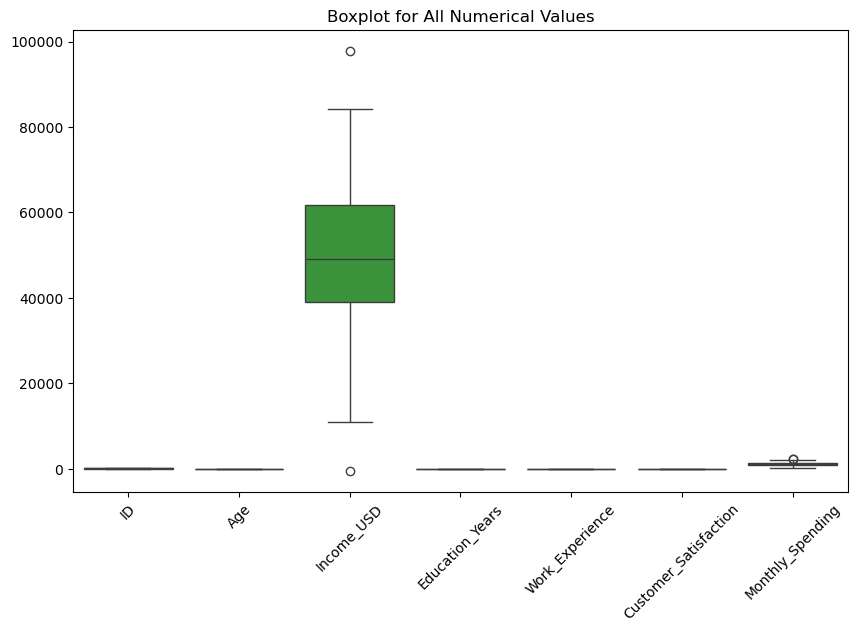

In [30]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = data)

# Customize plot
plt.xticks(rotation = 45)
plt.title("Boxplot for All Numerical Values")
plt.show()

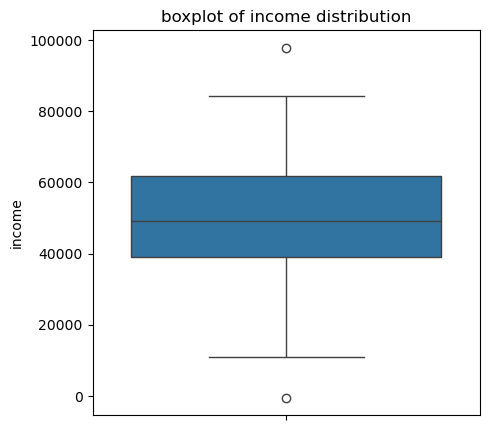

In [31]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data, y = "Income_USD")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

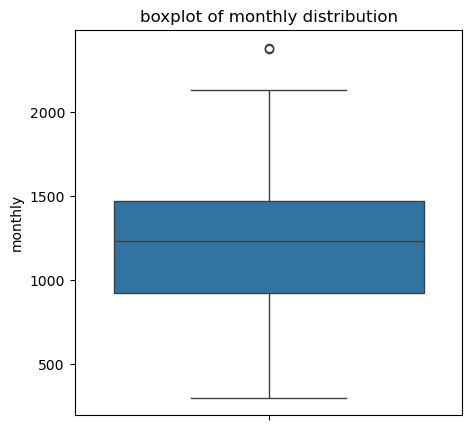

In [32]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = data, y = "Monthly_Spending")
plt.title("boxplot of monthly distribution")
plt.ylabel("monthly")
plt.show()

In [33]:
# Calculate IQR
Q1 = data['Income_USD'].quantile(0.25)
Q3 = data['Income_USD'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# remove outliers
df = data[(data['Income_USD'] >= lower_bound) & (data['Income_USD'] <= upper_bound)]

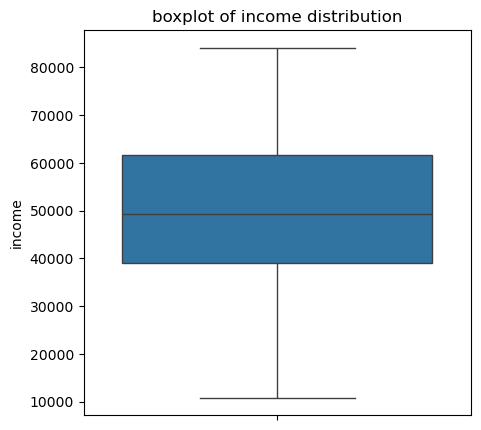

In [34]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = df, y = "Income_USD")
plt.title("boxplot of income distribution")
plt.ylabel("income")
plt.show()

In [35]:
# Calculate IQR
Q1 = data['Monthly_Spending'].quantile(0.25)
Q3 = data['Monthly_Spending'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# remove outliers
df = data[(data['Monthly_Spending'] >= lower_bound) & (data['Monthly_Spending'] <= upper_bound)]

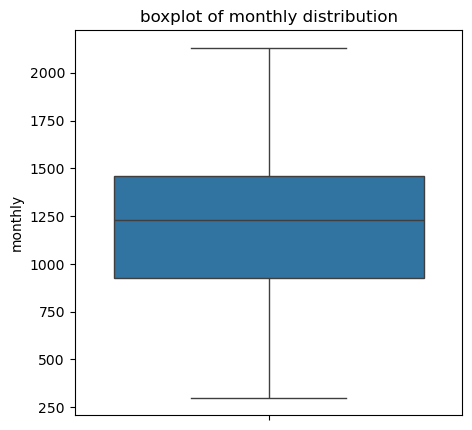

In [36]:
plt.figure(figsize = (5, 5))
sns.boxplot(data = df, y = "Monthly_Spending")
plt.title("boxplot of monthly distribution")
plt.ylabel("monthly")
plt.show()

In [37]:
summary_statistics = df.describe()
summary_statistics

,ID,Age,Income_USD,Education_Years,Work_Experience,Customer_Satisfaction,Monthly_Spending
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,153.803279,40.454918,49525.119385,13.852459,20.676230,5.405738,1213.769508
std,84.782621,13.312407,16261.865299,3.589358,11.401289,2.930492,381.064425
min,2.000000,18.000000,-461.430000,8.000000,0.000000,1.000000,300.360000
25%,85.500000,28.750000,38988.937500,11.000000,11.000000,3.000000,923.722500
50%,155.500000,41.500000,49212.850000,14.000000,21.500000,5.000000,1229.635000
75%,225.750000,52.000000,61922.515000,17.000000,30.250000,8.000000,1460.122500
max,299.000000,64.000000,97805.500000,20.000000,39.000000,10.000000,2131.450000


In [38]:
summary_statistics = df.drop(columns = ['ID']).describe()
summary_statistics

,Age,Income_USD,Education_Years,Work_Experience,Customer_Satisfaction,Monthly_Spending
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,40.454918,49525.119385,13.852459,20.676230,5.405738,1213.769508
std,13.312407,16261.865299,3.589358,11.401289,2.930492,381.064425
min,18.000000,-461.430000,8.000000,0.000000,1.000000,300.360000
25%,28.750000,38988.937500,11.000000,11.000000,3.000000,923.722500
50%,41.500000,49212.850000,14.000000,21.500000,5.000000,1229.635000
75%,52.000000,61922.515000,17.000000,30.250000,8.000000,1460.122500
max,64.000000,97805.500000,20.000000,39.000000,10.000000,2131.450000


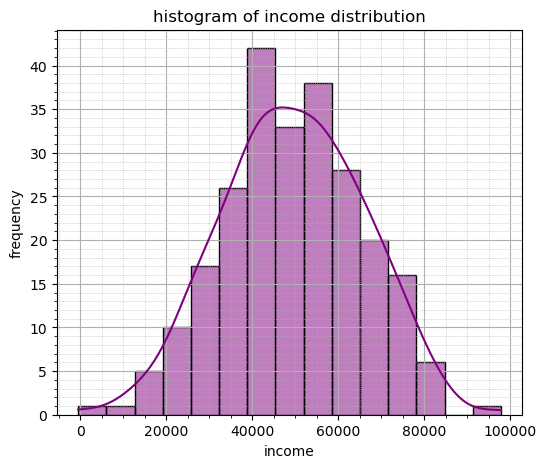

In [39]:
plt.figure(figsize = (6, 5))
sns.histplot(data = df, x = 'Income_USD', bins = 15, kde = True, color = 'purple')
plt.xlabel('income')
plt.ylabel('frequency')
plt.title('histogram of income distribution')
plt.minorticks_on()
plt.grid(which = 'minor', linestyle = ':', linewidth = 0.5)
plt.grid(True)
plt.show()

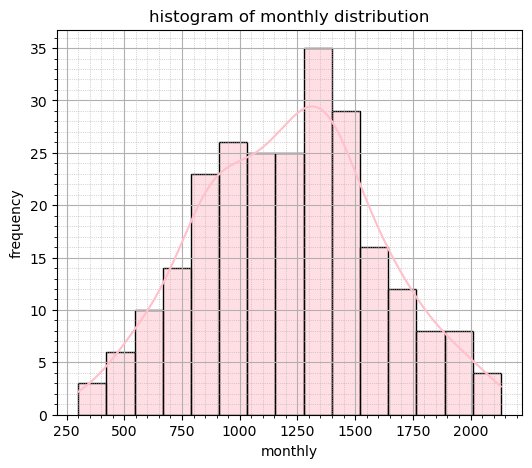

In [40]:
plt.figure(figsize = (6, 5))
sns.histplot(data = df, x = 'Monthly_Spending', bins = 15, kde = True, color = 'pink')
plt.xlabel('monthly')
plt.ylabel('frequency')
plt.title('histogram of monthly distribution')
plt.minorticks_on()
plt.grid(which = 'minor', linestyle = ':', linewidth = 0.5)
plt.grid(True)
plt.show()

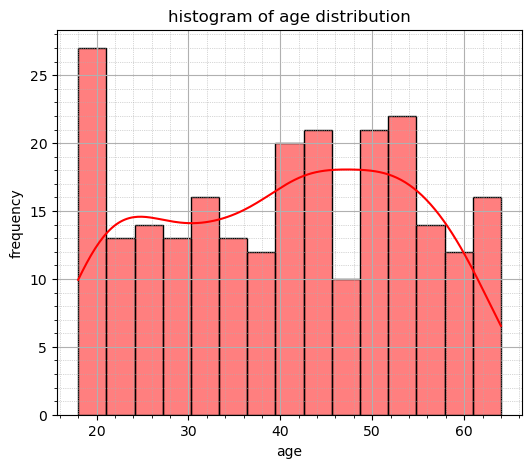

In [41]:
plt.figure(figsize = (6, 5))
sns.histplot(data = df, x = 'Age', bins = 15, kde = True, color = 'red')
plt.xlabel('age')
plt.ylabel('frequency')
plt.title('histogram of age distribution')
plt.minorticks_on()
plt.grid(which = 'minor', linestyle = ':', linewidth = 0.5)
plt.grid(True)
plt.show()

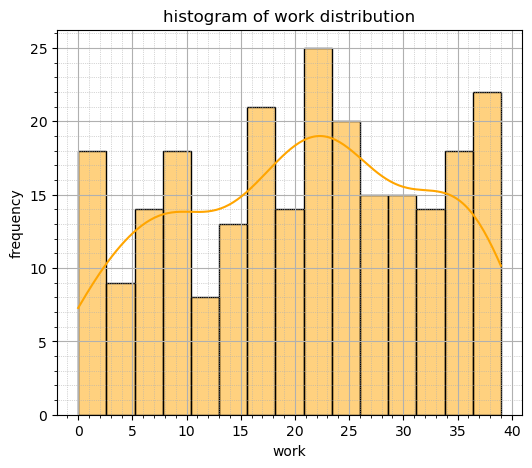

In [42]:
plt.figure(figsize = (6, 5))
sns.histplot(data = df, x = 'Work_Experience', bins = 15, kde = True, color = 'orange')
plt.xlabel('work')
plt.ylabel('frequency')
plt.title('histogram of work distribution')
plt.minorticks_on()
plt.grid(which = 'minor', linestyle = ':', linewidth = 0.5)
plt.grid(True)
plt.show()

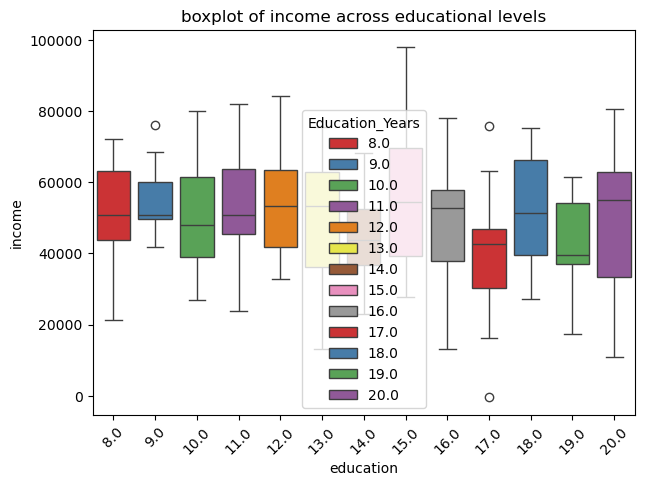

In [43]:
plt.figure(figsize = (7, 5))
sns.boxplot(data = df, x = 'Education_Years', y = 'Income_USD', hue = 'Education_Years', palette = 'Set1')
plt.xticks(rotation = 45)
plt.xlabel('education')
plt.ylabel('income')
plt.title('boxplot of income across educational levels')
plt.show()

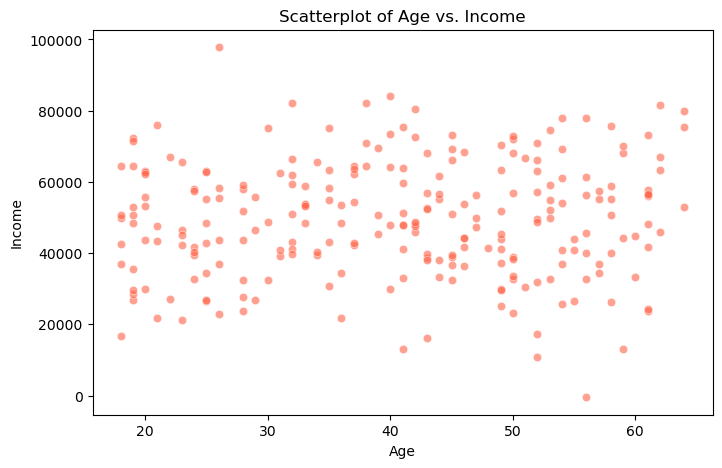

In [45]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'Age', y = 'Income_USD', color = 'tomato', alpha = 0.6)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Scatterplot of Age vs. Income')
plt.show()